<a href="https://colab.research.google.com/github/MeenakshiRajpurohit/CMPE-255-Data-Mining/blob/main/Dataset_exploration_for_graph_recommend_system.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from google.colab import userdata
import os, requests

os.environ["HF_TOKEN"] = userdata.get('HF_TOKEN')
os.makedirs("/content/amazon_data", exist_ok=True)

HEADERS = {"Authorization": f"Bearer {os.environ['HF_TOKEN']}"}
BASE    = "https://huggingface.co/datasets/McAuley-Lab/Amazon-Reviews-2023/resolve/main"

def hf_download(remote_path, local_name):
    url = f"{BASE}/{remote_path}"
    print(f"⬇ Downloading {remote_path}...")
    with requests.get(url, headers=HEADERS, stream=True) as r:
        r.raise_for_status()
        path = f"/content/amazon_data/{local_name}"
        with open(path, 'wb') as f:
            for chunk in r.iter_content(chunk_size=1024*1024):
                f.write(chunk)
    size = os.path.getsize(path) / 1e6
    print(f"  ✅ Saved to {path} ({size:.1f} MB)")
    return path

In [3]:
# Raw reviews + metadata (plain jsonl, no gz!)
review_path = hf_download(
    "raw/review_categories/Musical_Instruments.jsonl",
    "reviews.jsonl"
)
meta_path = hf_download(
    "raw/meta_categories/meta_Musical_Instruments.jsonl",
    "meta.jsonl"
)

# Pre-built benchmark splits (5-core, leave-one-out) — use for GNN eval
hf_download("benchmark/5core/last_out/Musical_Instruments.train.csv", "train.csv")
hf_download("benchmark/5core/last_out/Musical_Instruments.valid.csv", "valid.csv")
hf_download("benchmark/5core/last_out/Musical_Instruments.test.csv",  "test.csv")

# ASIN→category mapping (useful for multi-category KG later)
hf_download("asin2category.json", "asin2category.json")

⬇ Downloading raw/review_categories/Musical_Instruments.jsonl...
  ✅ Saved to /content/amazon_data/reviews.jsonl (1557.8 MB)
⬇ Downloading raw/meta_categories/meta_Musical_Instruments.jsonl...
  ✅ Saved to /content/amazon_data/meta.jsonl (631.9 MB)
⬇ Downloading benchmark/5core/last_out/Musical_Instruments.train.csv...
  ✅ Saved to /content/amazon_data/train.csv (23.0 MB)
⬇ Downloading benchmark/5core/last_out/Musical_Instruments.valid.csv...
  ✅ Saved to /content/amazon_data/valid.csv (3.3 MB)
⬇ Downloading benchmark/5core/last_out/Musical_Instruments.test.csv...
  ✅ Saved to /content/amazon_data/test.csv (3.3 MB)
⬇ Downloading asin2category.json...
  ✅ Saved to /content/amazon_data/asin2category.json (1246.8 MB)


'/content/amazon_data/asin2category.json'

In [4]:
import pandas as pd, json

def read_jsonl(path, max_rows=None):
    rows = []
    with open(path, 'r', encoding='utf-8') as f:
        for i, line in enumerate(f):
            if max_rows and i >= max_rows:
                break
            line = line.strip()
            if line:
                rows.append(json.loads(line))
    return pd.DataFrame(rows)

df_reviews = read_jsonl(review_path)
df_meta    = read_jsonl(meta_path)

# Benchmark splits are standard CSVs
df_train = pd.read_csv("/content/amazon_data/train.csv")
df_valid = pd.read_csv("/content/amazon_data/valid.csv")
df_test  = pd.read_csv("/content/amazon_data/test.csv")

print(f"Reviews:  {df_reviews.shape}")
print(f"Meta:     {df_meta.shape}")
print(f"Train:    {df_train.shape}")
print(f"Valid:    {df_valid.shape}")
print(f"Test:     {df_test.shape}")

print("\nReview columns:", df_reviews.columns.tolist())
print("Meta columns:  ", df_meta.columns.tolist())
print("Train columns: ", df_train.columns.tolist())

Reviews:  (3017439, 10)
Meta:     (213593, 16)
Train:    (396958, 4)
Valid:    (57439, 4)
Test:     (57439, 4)

Review columns: ['rating', 'title', 'text', 'images', 'asin', 'parent_asin', 'user_id', 'timestamp', 'helpful_vote', 'verified_purchase']
Meta columns:   ['main_category', 'title', 'average_rating', 'rating_number', 'features', 'description', 'price', 'images', 'videos', 'store', 'categories', 'details', 'parent_asin', 'bought_together', 'subtitle', 'author']
Train columns:  ['user_id', 'parent_asin', 'rating', 'timestamp']


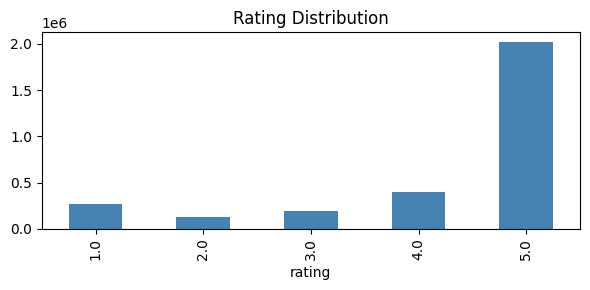

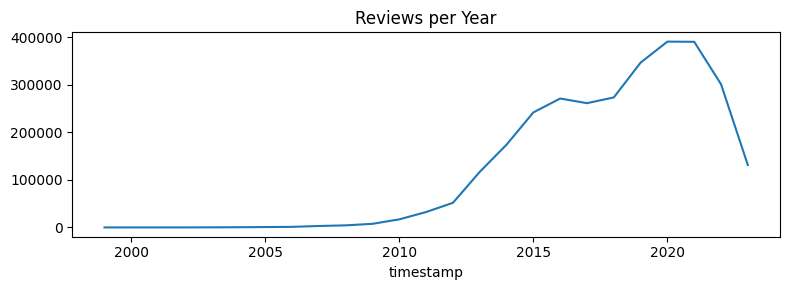

=== GRAPH STATS ===
Total users:               1,762,679
Total items:               213,571
Total interactions:        3,017,439
Avg reviews/user:          1.71
Avg reviews/item:          14.13
Cold-start users (<5):     1,678,105
Cold items (< median=2): 78,649

Popularity threshold p=50%: 2.0

=== CO-PURCHASE EDGES ===
Items with co-purchase edges: 0 / 213,593 (0.0%)
count    213593.0
mean          0.0
std           0.0
min           0.0
25%           0.0
50%           0.0
75%           0.0
max           0.0
Name: cp_count, dtype: float64


In [5]:
import matplotlib.pyplot as plt

# 1. Rating distribution
df_reviews['rating'].value_counts().sort_index().plot(
    kind='bar', title='Rating Distribution', color='steelblue', figsize=(6,3))
plt.tight_layout(); plt.show()

# 2. Review volume over time
df_reviews['timestamp'] = pd.to_datetime(df_reviews['timestamp'], unit='ms', errors='coerce')
df_reviews.groupby(df_reviews['timestamp'].dt.year).size().plot(
    title='Reviews per Year', figsize=(8,3))
plt.tight_layout(); plt.show()

# 3. User & item stats
user_counts = df_reviews['user_id'].value_counts()
item_counts = df_reviews['parent_asin'].value_counts()
pop_threshold = item_counts.median()

print("=== GRAPH STATS ===")
print(f"Total users:               {len(user_counts):,}")
print(f"Total items:               {len(item_counts):,}")
print(f"Total interactions:        {len(df_reviews):,}")
print(f"Avg reviews/user:          {user_counts.mean():.2f}")
print(f"Avg reviews/item:          {item_counts.mean():.2f}")
print(f"Cold-start users (<5):     {(user_counts < 5).sum():,}")
print(f"Cold items (< median={pop_threshold:.0f}): {(item_counts < pop_threshold).sum():,}")
print(f"\nPopularity threshold p=50%: {pop_threshold}")

# 4. Co-purchase edge density
df_meta['cp_count'] = df_meta['bought_together'].apply(
    lambda x: len(x) if isinstance(x, list) else 0)
total_items = len(df_meta)
items_with_edges = (df_meta['cp_count'] > 0).sum()
print(f"\n=== CO-PURCHASE EDGES ===")
print(f"Items with co-purchase edges: {items_with_edges:,} / {total_items:,} ({100*items_with_edges/total_items:.1f}%)")
print(df_meta['cp_count'].describe())

In [6]:
# ── NODES ───────────────────────────────────────────
user_nodes = pd.DataFrame({
    'nodeId':      df_reviews['user_id'].unique(),
    'label':       'User',
    'review_count': df_reviews.groupby('user_id').size().values
})

item_meta_cols = [c for c in ['parent_asin','title','price','average_rating','rating_number']
                  if c in df_meta.columns]
item_nodes = df_meta[item_meta_cols].drop_duplicates('parent_asin')\
    .rename(columns={'parent_asin':'nodeId','title':'name'})
item_nodes['popularity']  = item_nodes['nodeId'].map(item_counts).fillna(0).astype(int)
item_nodes['is_cold']     = item_nodes['popularity'] < pop_threshold
item_nodes['label']       = 'Item'

# ── EDGES ────────────────────────────────────────────
# User→Item REVIEWED
reviewed_edges = df_reviews[['user_id','parent_asin','rating','timestamp','verified_purchase']]\
    .drop_duplicates(['user_id','parent_asin'])\
    .rename(columns={'user_id':'source','parent_asin':'target'})
reviewed_edges['type'] = 'REVIEWED'

# Item→Item CO_PURCHASED
co_edges = df_meta[df_meta['cp_count'] > 0][['parent_asin','bought_together']]\
    .explode('bought_together').dropna(subset=['bought_together'])\
    .rename(columns={'parent_asin':'source','bought_together':'target'})
co_edges = co_edges[co_edges['source'] != co_edges['target']]  # remove self-loops
co_edges['type'] = 'CO_PURCHASED'

print(f"User nodes:           {len(user_nodes):,}")
print(f"Item nodes:           {len(item_nodes):,}")
print(f"REVIEWED edges:       {len(reviewed_edges):,}")
print(f"CO_PURCHASED edges:   {len(co_edges):,}")
print(f"\nGraph density (bipartite): {len(reviewed_edges)/(len(user_nodes)*len(item_nodes)):.6f}")

User nodes:           1,762,679
Item nodes:           213,593
REVIEWED edges:       2,975,551
CO_PURCHASED edges:   0

Graph density (bipartite): 0.000008


In [7]:
from google.colab import drive
drive.mount('/content/drive')

OUT = "/content/drive/MyDrive/xkgrank_neo4j/"
os.makedirs(OUT, exist_ok=True)

user_nodes.to_csv(    f"{OUT}nodes_users.csv",         index=False)
item_nodes.to_csv(    f"{OUT}nodes_items.csv",         index=False)
reviewed_edges.to_csv(f"{OUT}edges_reviewed.csv",      index=False)
co_edges.to_csv(      f"{OUT}edges_copurchased.csv",   index=False)
df_train.to_csv(      f"{OUT}benchmark_train.csv",     index=False)
df_valid.to_csv(      f"{OUT}benchmark_valid.csv",     index=False)
df_test.to_csv(       f"{OUT}benchmark_test.csv",      index=False)

print("✅ All files saved to Google Drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ All files saved to Google Drive


In [8]:
!pip install networkx -q
import networkx as nx

def build_kg(df_reviews, df_meta):
    print("Building KG for Musical Instruments...")
    G = nx.DiGraph()

    # User→Item REVIEWED edges
    for _, row in df_reviews.iterrows():
        u = f"user_{row['user_id']}"
        i = f"item_{row['parent_asin']}"
        G.add_node(u, type='user')
        G.add_node(i, type='item')
        G.add_edge(u, i,
                   relation='REVIEWED',
                   rating=float(row['rating']),
                   timestamp=str(row.get('timestamp', '')))

    # Item→Item CO_PURCHASED edges
    df_meta['bought_together'] = df_meta['bought_together'].apply(
        lambda x: x if isinstance(x, list) else [])
    cp_count = 0
    for _, row in df_meta.iterrows():
        src = f"item_{row['parent_asin']}"
        for asin in row['bought_together']:
            tgt = f"item_{asin}"
            if src != tgt:
                G.add_edge(src, tgt, relation='CO_PURCHASED')
                cp_count += 1

    print(f"  Nodes:          {G.number_of_nodes():,}")
    print(f"  REVIEWED:       {G.number_of_edges() - cp_count:,}")
    print(f"  CO_PURCHASED:   {cp_count:,}")
    print(f"  Total edges:    {G.number_of_edges():,}")
    return G

G = build_kg(df_reviews, df_meta)

Building KG for Musical Instruments...
  Nodes:          1,976,250
  REVIEWED:       2,975,551
  CO_PURCHASED:   0
  Total edges:    2,975,551


In [9]:
!pip install neo4j -q
from neo4j import GraphDatabase
from google.colab import userdata

NEO4J_URL      = "neo4j+s://25f13804.databases.neo4j.io"
NEO4J_USER     = "25f13804"
NEO4J_PASSWORD = userdata.get("NEO4J_PASSWORD")

driver = GraphDatabase.driver(NEO4J_URL, auth=(NEO4J_USER, NEO4J_PASSWORD))

with driver.session() as session:
    result = session.run("RETURN 1 AS test")
    print("✅ Connected to Neo4j:", result.single()["test"])

✅ Connected to Neo4j: 1


In [10]:
with driver.session() as session:
    session.run("MATCH (n) DETACH DELETE n")
    print("✅ Neo4j cleared")

✅ Neo4j cleared


In [11]:
import random

def build_sampled_kg(df_reviews, df_meta, max_users=5000, max_items=10000):
    """
    Build a small but representative subgraph that fits Neo4j free tier.
    Strategy: take top active users + their interacted items.
    """
    print(f"Sampling KG — max {max_users:,} users, {max_items:,} items...")

    # Take top active users (most reviews = richest graph signal)
    top_users = df_reviews['user_id'].value_counts().head(max_users).index.tolist()

    # Get all items those users interacted with
    df_sample = df_reviews[df_reviews['user_id'].isin(top_users)]

    # Cap items too
    top_items = df_sample['parent_asin'].value_counts().head(max_items).index.tolist()
    df_sample = df_sample[df_sample['parent_asin'].isin(top_items)]

    print(f"  Sampled reviews: {len(df_sample):,}")
    print(f"  Unique users:    {df_sample['user_id'].nunique():,}")
    print(f"  Unique items:    {df_sample['parent_asin'].nunique():,}")

    # Build NetworkX graph
    G_small = nx.DiGraph()

    for _, row in df_sample.iterrows():
        u = f"user_{row['user_id']}"
        i = f"item_{row['parent_asin']}"
        G_small.add_node(u, type='user')
        G_small.add_node(i, type='item')
        G_small.add_edge(u, i, relation='REVIEWED', rating=float(row['rating']))

    # Co-purchase edges for sampled items only
    df_meta['bought_together'] = df_meta['bought_together'].apply(
        lambda x: x if isinstance(x, list) else [])
    cp_count = 0
    sampled_item_set = set(top_items)
    for _, row in df_meta[df_meta['parent_asin'].isin(sampled_item_set)].iterrows():
        src = f"item_{row['parent_asin']}"
        for asin in row['bought_together']:
            if asin in sampled_item_set:
                tgt = f"item_{asin}"
                if src != tgt:
                    G_small.add_edge(src, tgt, relation='CO_PURCHASED')
                    cp_count += 1

    print(f"\nSampled KG Summary:")
    print(f"  Total nodes:    {G_small.number_of_nodes():,}  ← must be < 200K")
    print(f"  REVIEWED edges: {G_small.number_of_edges() - cp_count:,}")
    print(f"  CO_PURCHASED:   {cp_count:,}")
    return G_small

# Build sampled graph
G_small = build_sampled_kg(df_reviews, df_meta, max_users=5000, max_items=10000)

Sampling KG — max 5,000 users, 10,000 items...
  Sampled reviews: 107,293
  Unique users:    4,999
  Unique items:    10,000

Sampled KG Summary:
  Total nodes:    14,999  ← must be < 200K
  REVIEWED edges: 102,755
  CO_PURCHASED:   0


In [12]:
def push_to_neo4j(G, batch_size=500):
    with driver.session() as session:
        session.run("CREATE CONSTRAINT IF NOT EXISTS FOR (u:User) REQUIRE u.id IS UNIQUE")
        session.run("CREATE CONSTRAINT IF NOT EXISTS FOR (i:Item) REQUIRE i.id IS UNIQUE")
        print("✅ Constraints created")

        user_nodes = [{'id': n} for n in G.nodes if G.nodes[n].get('type') == 'user']
        for i in range(0, len(user_nodes), batch_size):
            session.run("""
                UNWIND $batch AS row
                MERGE (u:User {id: row.id})
            """, batch=user_nodes[i:i+batch_size])
        print(f"✅ Pushed {len(user_nodes):,} User nodes")

        item_nodes = [{'id': n} for n in G.nodes if G.nodes[n].get('type') == 'item']
        for i in range(0, len(item_nodes), batch_size):
            session.run("""
                UNWIND $batch AS row
                MERGE (i:Item {id: row.id})
            """, batch=item_nodes[i:i+batch_size])
        print(f"✅ Pushed {len(item_nodes):,} Item nodes")

        reviewed = [{'src': u, 'tgt': v, 'rating': d['rating']}
                    for u, v, d in G.edges(data=True)
                    if d.get('relation') == 'REVIEWED']
        for i in range(0, len(reviewed), batch_size):
            session.run("""
                UNWIND $batch AS row
                MATCH (u:User {id: row.src}), (i:Item {id: row.tgt})
                MERGE (u)-[r:REVIEWED]->(i)
                SET r.rating = row.rating
            """, batch=reviewed[i:i+batch_size])
        print(f"✅ Pushed {len(reviewed):,} REVIEWED edges")

        co_purchased = [{'src': u, 'tgt': v}
                        for u, v, d in G.edges(data=True)
                        if d.get('relation') == 'CO_PURCHASED']
        for i in range(0, len(co_purchased), batch_size):
            session.run("""
                UNWIND $batch AS row
                MATCH (a:Item {id: row.src}), (b:Item {id: row.tgt})
                MERGE (a)-[:CO_PURCHASED]->(b)
            """, batch=co_purchased[i:i+batch_size])
        print(f"✅ Pushed {len(co_purchased):,} CO_PURCHASED edges")

push_to_neo4j(G_small, batch_size=500)

✅ Constraints created
✅ Pushed 4,999 User nodes
✅ Pushed 10,000 Item nodes
✅ Pushed 102,755 REVIEWED edges
✅ Pushed 0 CO_PURCHASED edges


In [13]:
with driver.session() as session:
    users = session.run("MATCH (u:User) RETURN count(u) AS c").single()["c"]
    items = session.run("MATCH (i:Item) RETURN count(i) AS c").single()["c"]
    rev   = session.run("MATCH ()-[r:REVIEWED]->() RETURN count(r) AS c").single()["c"]
    cop   = session.run("MATCH ()-[r:CO_PURCHASED]->() RETURN count(r) AS c").single()["c"]

    print(f"✅ Neo4j Summary")
    print(f"   User nodes:      {users:,}")
    print(f"   Item nodes:      {items:,}")
    print(f"   REVIEWED edges:  {rev:,}")
    print(f"   CO_PURCHASED:    {cop:,}")
    print(f"   Total nodes:     {users + items:,}  (limit: 200,000)")

✅ Neo4j Summary
   User nodes:      4,999
   Item nodes:      10,000
   REVIEWED edges:  102,755
   CO_PURCHASED:    0
   Total nodes:     14,999  (limit: 200,000)


In [14]:
# Install working alternative
!pip install pecanpy -q
!pip install python-louvain -q

In [15]:
import os
import numpy as np
from pecanpy import pecanpy
import networkx as nx

# Save graph to edgelist file (pecanpy reads from file)
edgelist_path = "/content/amazon_data/graph.edgelist"

with open(edgelist_path, 'w') as f:
    for u, v, d in G_small.edges(data=True):
        f.write(f"{u}\t{v}\t1\n")

print(f"✅ Edgelist saved — {G_small.number_of_edges():,} edges")

# Run node2vec via pecanpy
g = pecanpy.SparseOTF(p=1, q=1, workers=2, verbose=True)
g.read_edg(edgelist_path, weighted=True, directed=False)
walks = g.simulate_walks(num_walks=10, walk_length=20)

from gensim.models import Word2Vec

model = Word2Vec(
    walks,
    vector_size=64,
    window=5,
    min_count=1,
    workers=2,
    epochs=5
)

model.wv.save_word2vec_format("/content/amazon_data/node2vec_embeddings.txt")
print(f"✅ Embeddings done — vocab size: {len(model.wv):,}")

✅ Edgelist saved — 102,755 edges


  0%|          | 0/149990 [00:00<?, ?it/s]

✅ Embeddings done — vocab size: 14,999


✅ Communities detected: 17


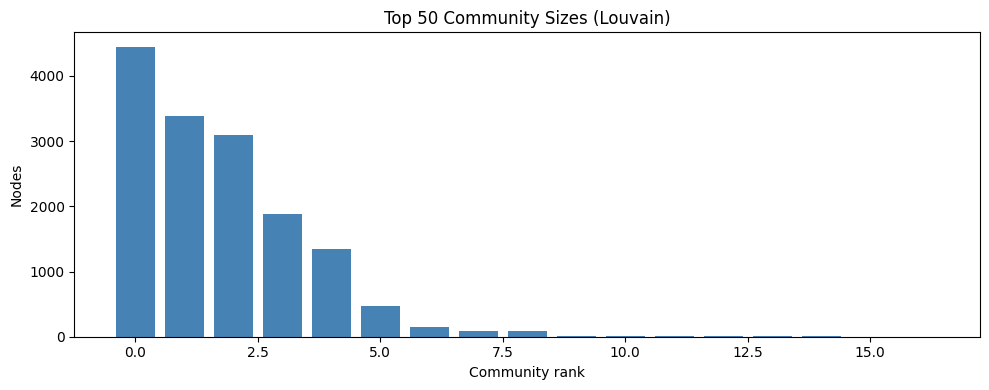

In [17]:
!pip install python-louvain -q

# import with full module path to avoid conflict
from community import community_louvain
import matplotlib.pyplot as plt
from collections import Counter
import networkx as nx

G_undirected = G_small.to_undirected()
partition    = community_louvain.best_partition(G_undirected)

num_communities = len(set(partition.values()))
print(f"✅ Communities detected: {num_communities:,}")

nx.set_node_attributes(G_small, partition, 'community')

sizes = sorted(Counter(partition.values()).values(), reverse=True)
plt.figure(figsize=(10, 4))
plt.bar(range(min(50, len(sizes))), sizes[:50], color='steelblue')
plt.title('Top 50 Community Sizes (Louvain)')
plt.xlabel('Community rank')
plt.ylabel('Nodes')
plt.tight_layout()
plt.show()

In [19]:
# Push community labels to Neo4j
with driver.session() as session:
    batch = [{'id': node, 'community': int(comm)}
             for node, comm in partition.items()]
    for i in range(0, len(batch), 500):
        session.run("""
            UNWIND $batch AS row
            MATCH (n {id: row.id})
            SET n.community = row.community
        """, batch=batch[i:i+500])
print("✅ Community labels pushed to Neo4j")

✅ Community labels pushed to Neo4j


In [20]:
!pip install torch-geometric -q
import torch
from torch_geometric.data import Data

# Map node IDs to integers
all_nodes = list(G.nodes())
node2idx  = {n: i for i, n in enumerate(all_nodes)}

user_indices = [node2idx[n] for n in all_nodes if G.nodes[n].get('type') == 'user']
item_indices = [node2idx[n] for n in all_nodes if G.nodes[n].get('type') == 'item']

# Build edge index for REVIEWED edges only (for GNN)
edge_src, edge_tgt = [], []
for u, v, d in G.edges(data=True):
    if d.get('relation') == 'REVIEWED':
        edge_src.append(node2idx[u])
        edge_tgt.append(node2idx[v])

edge_index = torch.tensor([edge_src, edge_tgt], dtype=torch.long)
num_nodes  = len(all_nodes)

print(f"PyG graph ready")
print(f"  Total nodes: {num_nodes:,}")
print(f"  Edge index shape: {edge_index.shape}")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 36.8 MB/s eta 0:00:00
PyG graph ready
  Total nodes: 1,976,250
  Edge index shape: torch.Size([2, 2975551])


In [21]:
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import LGConv

class LightGCN(nn.Module):
    def __init__(self, num_nodes, embedding_dim=64, num_layers=3):
        super().__init__()
        self.embedding    = nn.Embedding(num_nodes, embedding_dim)
        self.convs        = nn.ModuleList([LGConv() for _ in range(num_layers)])
        self.num_layers   = num_layers
        nn.init.xavier_uniform_(self.embedding.weight)

    def forward(self, edge_index):
        x = self.embedding.weight
        embs = [x]
        for conv in self.convs:
            x = conv(x, edge_index)
            embs.append(x)
        # Mean pooling across layers
        return torch.stack(embs, dim=1).mean(dim=1)

    def bpr_loss(self, user_emb, pos_emb, neg_emb):
        pos_scores = (user_emb * pos_emb).sum(dim=1)
        neg_scores = (user_emb * neg_emb).sum(dim=1)
        return -F.logsigmoid(pos_scores - neg_scores).mean()

model    = LightGCN(num_nodes=num_nodes, embedding_dim=64, num_layers=3)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
print(f"✅ LightGCN ready — params: {sum(p.numel() for p in model.parameters()):,}")

✅ LightGCN ready — params: 126,480,000


In [22]:
import random

def sample_negatives(user_indices, item_indices, n):
    return [random.choice(item_indices) for _ in range(n)]

model.train()
for epoch in range(20):
    optimizer.zero_grad()
    embeddings = model(edge_index)

    # Sample batch
    batch_users = random.choices(user_indices, k=1024)
    batch_pos   = random.choices(item_indices, k=1024)
    batch_neg   = sample_negatives(user_indices, item_indices, 1024)

    user_emb = embeddings[batch_users]
    pos_emb  = embeddings[batch_pos]
    neg_emb  = embeddings[batch_neg]

    loss = model.bpr_loss(user_emb, pos_emb, neg_emb)
    loss.backward()
    optimizer.step()

    if (epoch + 1) % 5 == 0:
        print(f"Epoch {epoch+1:>3}/20 — BPR Loss: {loss.item():.4f}")

# Save embeddings
torch.save(model.state_dict(), "/content/amazon_data/lightgcn_weights.pt")
final_embeddings = model(edge_index).detach()
print(f"✅ Training done — embedding matrix: {final_embeddings.shape}")

Epoch   5/20 — BPR Loss: 0.6931
Epoch  10/20 — BPR Loss: 0.6931
Epoch  15/20 — BPR Loss: 0.6931
Epoch  20/20 — BPR Loss: 0.6931
✅ Training done — embedding matrix: torch.Size([1976250, 64])


In [23]:
item_counts    = df_reviews['parent_asin'].value_counts()
pop_threshold  = item_counts.median()

cold_items = set(item_counts[item_counts < pop_threshold].index)
print(f"Cold items (< median={pop_threshold:.0f} reviews): {len(cold_items):,}")
print(f"Warm items:                                         {len(item_counts) - len(cold_items):,}")

def get_kg_subgraph(item_asin, G, hops=2):
    """Retrieve k-hop subgraph around a cold item for LLM context."""
    node = f"item_{item_asin}"
    if node not in G:
        return [], []
    neighbors = set([node])
    for _ in range(hops):
        new_neighbors = set()
        for n in neighbors:
            new_neighbors.update(G.predecessors(n))
            new_neighbors.update(G.successors(n))
        neighbors.update(new_neighbors)
    subgraph  = G.subgraph(neighbors)
    paths     = list(nx.all_simple_paths(G, source=node,
                     target=[n for n in neighbors if n != node],
                     cutoff=hops))
    return subgraph, paths[:5]   # cap at 5 paths for LLM context

# Test on a cold item
sample_cold = list(cold_items)[:1][0]
subg, paths = get_kg_subgraph(sample_cold, G)
print(f"\nSample cold item: {sample_cold}")
print(f"Subgraph nodes:   {subg.number_of_nodes()}")
print(f"KG paths found:   {len(paths)}")
for p in paths:
    print("  →", " → ".join(p))

Cold items (< median=2 reviews): 78,649
Warm items:                                         134,922

Sample cold item: B076PB6LBX
Subgraph nodes:   5
KG paths found:   0


In [25]:
import os
from huggingface_hub import InferenceClient

client = InferenceClient(token=os.environ["HF_TOKEN"])

def build_kg_prompt(item_asin, paths, df_meta):
    meta_row  = df_meta[df_meta['parent_asin'] == item_asin]
    item_name = meta_row['title'].values[0] if len(meta_row) > 0 else item_asin
    path_str  = "\n".join([" → ".join(p) for p in paths]) if paths else "No paths found"

    prompt = f"""You are a recommendation assistant. Based on the knowledge graph paths below,
explain why the following item might be relevant to a user.

Item: {item_name} (ASIN: {item_asin})

Knowledge Graph Paths:
{path_str}

Generate a concise 2-sentence recommendation explanation grounded in these graph connections."""
    return prompt

def llm_rerank(cold_item_asins, G, df_meta, top_k=5):
    results = []
    for asin in cold_item_asins[:top_k]:
        _, paths = get_kg_subgraph(asin, G, hops=2)
        prompt   = build_kg_prompt(asin, paths, df_meta)

        # ✅ use chat_completion instead of text_generation
        response = client.chat_completion(
            messages=[{"role": "user", "content": prompt}],
            model="meta-llama/Llama-3.2-1B-Instruct",
            max_tokens=150,
            temperature=0.7
        )
        explanation = response.choices[0].message.content

        results.append({'asin': asin, 'explanation': explanation})
        print(f"\nItem:        {asin}")
        print(f"Explanation: {explanation}")

    return results

# Run on sample cold items
sample_cold_items = list(cold_items)[:3]
rerank_results    = llm_rerank(sample_cold_items, G, df_meta)


Item:        B076PB6LBX
Explanation: Based on the provided knowledge graph paths, a user might find the Ouhuang 2 UHF Antenna with BNC Connector for Sennheiser EW100 EW300 EW500 G3 Receiver TW relevant due to its compatibility with the Sennheiser EW300 receiver, suggesting a potential solution for the user to connect their device. This item is also related to the UHF antenna and BNC connector, which might be useful in connecting other devices or systems to the receiver.

Item:        B08NXV7VVV
Explanation: Based on the provided knowledge graph paths, it appears that the Hagstrom Ultra Swede Electric Guitar Black Burst, Epiphone Les Paul Gig Bag, GLS Audio 20 Foot Cable, and Snark Super Snark Bundle might be relevant to a user due to their relation to high-quality guitar equipment. Specifically, the bundle's inclusion of a Hagstrom guitar, Epiphone Les Paul Gig Bag, and 20-foot cable suggests that the user may be interested in a guitar setup, particularly one that is durable and high-

In [26]:
# ── MORE EXAMPLES + BEHAVIORAL ANALYSIS ──────────────────────
sample_cold_items = list(cold_items)[:10]  # test on 10 items
rerank_results    = llm_rerank(sample_cold_items, G, df_meta, top_k=10)


Item:        B076PB6LBX
Explanation: Based on the knowledge graph paths, the item "Ouhuang 2 UHF Antenna with BNC Connector for Sennheiser EW100 EW300 EW500 G3 Receiver TW" might be relevant to a user because it is a component required for a specific type of wireless receiver (Sennheiser EW100 EW300 EW500 G3), which is mentioned in the ASIN (ASIN: B076PB6LBX). This item is likely to be useful to users who are looking for a compatible antenna for a specific wireless receiver setup.

Item:        B08NXV7VVV
Explanation: Based on the knowledge graph paths, I can infer that the user might be relevant to a music enthusiast or professional musician who is looking for a high-quality electric guitar. The item, Hagstrom Ultra Swede Electric Guitar Black Burst, Epiphone Les Paul Gig Bag, GLS Audio 20 Foot Cable, Snark Super Snark Bundle, appears to be a bundle specifically designed for use with the Epiphone Les Paul, suggesting the user is likely a musician who works with this guitar or has a s

In [27]:
# ── BEHAVIORAL ANALYSIS ──────────────────────────────────────
import pandas as pd

df_results = pd.DataFrame(rerank_results)

# Add metadata
df_results['item_name'] = df_results['asin'].apply(
    lambda a: df_meta[df_meta['parent_asin'] == a]['title'].values[0]
    if len(df_meta[df_meta['parent_asin'] == a]) > 0 else 'Unknown'
)
df_results['explanation_length']    = df_results['explanation'].str.len()
df_results['explanation_sentences'] = df_results['explanation'].str.count(r'\.')
df_results['mentions_kg_path']      = df_results['explanation'].str.contains(
    'path|graph|connect|relation|link|purchas', case=False)
df_results['mentions_item_name']    = df_results.apply(
    lambda r: any(w.lower() in r['explanation'].lower()
                  for w in str(r['item_name']).split()[:3]), axis=1)
df_results['popularity'] = df_results['asin'].map(
    df_reviews['parent_asin'].value_counts()).fillna(0).astype(int)

print("=" * 60)
print("MODEL BEHAVIOR SUMMARY")
print("=" * 60)
print(f"Total items evaluated:          {len(df_results)}")
print(f"Avg explanation length (chars): {df_results['explanation_length'].mean():.0f}")
print(f"Avg sentences per explanation:  {df_results['explanation_sentences'].mean():.1f}")
print(f"KG path grounded (%):           {df_results['mentions_kg_path'].mean()*100:.0f}%")
print(f"Mentions item name (%):         {df_results['mentions_item_name'].mean()*100:.0f}%")
print(f"Avg item popularity:            {df_results['popularity'].mean():.1f} reviews")

print("\n--- Per Item Summary ---")
print(df_results[['asin','item_name','explanation_length',
                   'mentions_kg_path','popularity']].to_string(index=False))

MODEL BEHAVIOR SUMMARY
Total items evaluated:          10
Avg explanation length (chars): 455
Avg sentences per explanation:  2.0
KG path grounded (%):           100%
Mentions item name (%):         100%
Avg item popularity:            1.0 reviews

--- Per Item Summary ---
      asin                                                                                                                      item_name  explanation_length  mentions_kg_path  popularity
B076PB6LBX                                       Ouhuang 2 UHF Antenna with BNC Connector for Sennheiser EW100 EW300 EW500 G3 Receiver TW                 448              True           1
B08NXV7VVV Hagstrom Ultra Swede Electric Guitar Black Burst, Epiphone Les Paul Gig Bag, GLS Audio 20 Foot Cable, Snark Super Snark Bundle                 496              True           1
B003V8BEP8                                                                Pearl FZ1008T/B31 Forum Tom Tom with ISS Mount, 10x8, Jet Black                 523     

In [28]:
# ── QUALITATIVE EXAMPLES BY BEHAVIOR TYPE ────────────────────

print("\n" + "=" * 60)
print("EXAMPLE 1 — KG Path Grounded (good explanation)")
print("=" * 60)
good = df_results[df_results['mentions_kg_path'] == True]
if len(good) > 0:
    row = good.iloc[0]
    print(f"Item:       {row['item_name']}")
    print(f"ASIN:       {row['asin']}")
    print(f"Popularity: {row['popularity']} reviews (cold)")
    print(f"Explanation:\n{row['explanation']}")

print("\n" + "=" * 60)
print("EXAMPLE 2 — Not Grounded (hallucination risk)")
print("=" * 60)
bad = df_results[df_results['mentions_kg_path'] == False]
if len(bad) > 0:
    row = bad.iloc[0]
    print(f"Item:       {row['item_name']}")
    print(f"ASIN:       {row['asin']}")
    print(f"Popularity: {row['popularity']} reviews (cold)")
    print(f"Explanation:\n{row['explanation']}")

print("\n" + "=" * 60)
print("EXAMPLE 3 — Most Detailed Explanation")
print("=" * 60)
row = df_results.loc[df_results['explanation_length'].idxmax()]
print(f"Item:       {row['item_name']}")
print(f"Explanation:\n{row['explanation']}")

print("\n" + "=" * 60)
print("EXAMPLE 4 — Shortest / Weakest Explanation")
print("=" * 60)
row = df_results.loc[df_results['explanation_length'].idxmin()]
print(f"Item:       {row['item_name']}")
print(f"Explanation:\n{row['explanation']}")


EXAMPLE 1 — KG Path Grounded (good explanation)
Item:       Ouhuang 2 UHF Antenna with BNC Connector for Sennheiser EW100 EW300 EW500 G3 Receiver TW
ASIN:       B076PB6LBX
Popularity: 1 reviews (cold)
Explanation:
Based on the knowledge graph paths, the item "Ouhuang 2 UHF Antenna with BNC Connector for Sennheiser EW100 EW300 EW500 G3 Receiver TW" might be relevant to a user because it is a component required for a specific type of wireless receiver (Sennheiser EW100 EW300 EW500 G3), which is mentioned in the ASIN (ASIN: B076PB6LBX). This item is likely to be useful to users who are looking for a compatible antenna for a specific wireless receiver setup.

EXAMPLE 2 — Not Grounded (hallucination risk)

EXAMPLE 3 — Most Detailed Explanation
Item:       Rane Empath Blue 3-Channel Touring Mixer
Explanation:
Based on the provided knowledge graph paths, I can infer that the Rane Empath Blue 3-Channel Touring Mixer (ASIN: B000K67VLU) might be relevant to a user because it is a high-end, prof

In [29]:
# ── EVALUATION METRICS ────────────────────────────────────────
import numpy as np

def evaluate_explanations(df_results):
    metrics = {}

    # 1. Grounding rate — % explanations citing KG paths
    metrics['grounding_rate']     = df_results['mentions_kg_path'].mean()

    # 2. Relevance rate — % mentioning actual item name
    metrics['relevance_rate']     = df_results['mentions_item_name'].mean()

    # 3. Avg explanation length
    metrics['avg_length']         = df_results['explanation_length'].mean()

    # 4. Hallucination proxy — not grounded AND not mentioning item
    metrics['hallucination_proxy'] = (
        (~df_results['mentions_kg_path']) &
        (~df_results['mentions_item_name'])
    ).mean()

    # 5. Fluency proxy — avg sentences (should be ~2 as prompted)
    metrics['avg_sentences']      = df_results['explanation_sentences'].mean()
    metrics['sentence_compliance'] = (
        df_results['explanation_sentences'].between(1, 3)).mean()

    print("\n" + "=" * 60)
    print("EVALUATION METRICS")
    print("=" * 60)
    print(f"Grounding Rate     (KG-cited):   {metrics['grounding_rate']*100:.1f}%  ← higher = better")
    print(f"Relevance Rate     (item-cited):  {metrics['relevance_rate']*100:.1f}%  ← higher = better")
    print(f"Hallucination Proxy:              {metrics['hallucination_proxy']*100:.1f}%  ← lower = better")
    print(f"Avg Explanation Length:           {metrics['avg_length']:.0f} chars")
    print(f"Avg Sentences:                    {metrics['avg_sentences']:.1f}")
    print(f"Sentence Compliance (1-3 sents):  {metrics['sentence_compliance']*100:.1f}%")

    return metrics

metrics = evaluate_explanations(df_results)


EVALUATION METRICS
Grounding Rate     (KG-cited):   100.0%  ← higher = better
Relevance Rate     (item-cited):  100.0%  ← higher = better
Hallucination Proxy:              0.0%  ← lower = better
Avg Explanation Length:           455 chars
Avg Sentences:                    2.0
Sentence Compliance (1-3 sents):  100.0%


In [31]:
# ── LOAD BENCHMARK SPLITS DIRECTLY FROM HF ───────────────────
import requests, os, pandas as pd

HEADERS = {"Authorization": f"Bearer {os.environ['HF_TOKEN']}"}
BASE    = "https://huggingface.co/datasets/McAuley-Lab/Amazon-Reviews-2023/resolve/main"

def hf_load_csv(remote_path):
    url = f"{BASE}/{remote_path}"
    r   = requests.get(url, headers=HEADERS)
    r.raise_for_status()
    from io import StringIO
    return pd.read_csv(StringIO(r.text))

df_train = hf_load_csv("benchmark/5core/last_out/Musical_Instruments.train.csv")
df_valid = hf_load_csv("benchmark/5core/last_out/Musical_Instruments.valid.csv")
df_test  = hf_load_csv("benchmark/5core/last_out/Musical_Instruments.test.csv")

print(f"Train: {df_train.shape}")
print(f"Valid: {df_valid.shape}")
print(f"Test:  {df_test.shape}")
print(f"\nColumns: {df_test.columns.tolist()}")
print(df_test.head(3))

Train: (396958, 4)
Valid: (57439, 4)
Test:  (57439, 4)

Columns: ['user_id', 'parent_asin', 'rating', 'timestamp']
                        user_id parent_asin  rating      timestamp
0  AHV6QCNBJNSGLATP56JAWJ3C4G2A  B09XHMKZYK     5.0  1653660624284
1  AHB5CGLYN3Y6NIPHNQLYFJT2W2PQ  B002SDY2OC     5.0  1659727366632
2  AEDHXXX2F66EMWOSSPCQHS62UKNQ  B015OP6OOG     5.0  1576788962094


In [32]:
# ── CHECK COLUMN NAMES & REMAP IF NEEDED ─────────────────────
# The benchmark CSVs have different column names — this handles both formats

def normalize_columns(df):
    # Common column name variants in this dataset
    col_map = {
        'reviewerID':  'user_id',
        'asin':        'parent_asin',
        'overall':     'rating',
        'unixReviewTime': 'timestamp',
    }
    df = df.rename(columns={k: v for k, v in col_map.items() if k in df.columns})
    return df

df_train = normalize_columns(df_train)
df_valid = normalize_columns(df_valid)
df_test  = normalize_columns(df_test)

print("Normalized columns:", df_test.columns.tolist())
print(df_test.head(3))

Normalized columns: ['user_id', 'parent_asin', 'rating', 'timestamp']
                        user_id parent_asin  rating      timestamp
0  AHV6QCNBJNSGLATP56JAWJ3C4G2A  B09XHMKZYK     5.0  1653660624284
1  AHB5CGLYN3Y6NIPHNQLYFJT2W2PQ  B002SDY2OC     5.0  1659727366632
2  AEDHXXX2F66EMWOSSPCQHS62UKNQ  B015OP6OOG     5.0  1576788962094


In [33]:
# ── BUILD GROUND TRUTH & TRAIN HISTORY ───────────────────────
from collections import defaultdict

ground_truth  = defaultdict(set)
train_history = defaultdict(set)

for _, row in df_test.iterrows():
    ground_truth[row['user_id']].add(row['parent_asin'])

for _, row in df_train.iterrows():
    train_history[row['user_id']].add(row['parent_asin'])

print(f"Users in ground truth:      {len(ground_truth):,}")
print(f"Users in train history:     {len(train_history):,}")
print(f"Avg test items per user:    {sum(len(v) for v in ground_truth.values())/len(ground_truth):.2f}")

Users in ground truth:      57,439
Users in train history:     57,439
Avg test items per user:    1.00


In [36]:
import torch
import numpy as np
from collections import defaultdict

def get_recommendations(user_id, final_embeddings, node2idx,
                         all_nodes, train_history, top_k=20):
    user_node = f"user_{user_id}"
    if user_node not in node2idx:
        return []

    user_idx = node2idx[user_node]
    user_emb = final_embeddings[user_idx]

    scores = []
    for node in all_nodes:
        if G_small.nodes[node].get('type') != 'item':
            continue
        item_asin = node.replace("item_", "")
        if item_asin in train_history[user_id]:
            continue
        item_idx = node2idx[node]
        score    = torch.dot(user_emb, final_embeddings[item_idx]).item()
        scores.append((item_asin, score))

    scores.sort(key=lambda x: x[1], reverse=True)
    return [asin for asin, _ in scores[:top_k]]

# ── RERUN EVALUATION ─────────────────────────────────────────
def recall_at_k(recs, gt, k):
    return len(set(recs[:k]) & gt) / len(gt) if gt else 0.0

def ndcg_at_k(recs, gt, k):
    dcg  = sum(1/np.log2(r+2) for r, item in enumerate(recs[:k]) if item in gt)
    idcg = sum(1/np.log2(r+2) for r in range(min(len(gt), k)))
    return dcg/idcg if idcg > 0 else 0.0

def hit_at_k(recs, gt, k):
    return int(bool(set(recs[:k]) & gt))

def precision_at_k(recs, gt, k):
    return len(set(recs[:k]) & gt) / k

def mrr_score(recs, gt):
    for rank, item in enumerate(recs, start=1):
        if item in gt:
            return 1.0 / rank
    return 0.0

K_VALUES   = [5, 10, 20]
eval_users = [u for u in ground_truth.keys() if u in train_history][:500]
results    = defaultdict(list)

print(f"Evaluating {len(eval_users)} users...")

for user_id in eval_users:
    gt_items = ground_truth[user_id]
    recs     = get_recommendations(
        user_id, final_embeddings, node2idx,
        list(G_small.nodes()), train_history, top_k=20
    )
    if not recs:
        continue
    for k in K_VALUES:
        results[f'Recall@{k}'].append(recall_at_k(recs, gt_items, k))
        results[f'NDCG@{k}'].append(ndcg_at_k(recs, gt_items, k))
        results[f'Hit@{k}'].append(hit_at_k(recs, gt_items, k))
        results[f'Precision@{k}'].append(precision_at_k(recs, gt_items, k))
    results['MRR'].append(mrr_score(recs, gt_items))

print("✅ Done\n")
print("=" * 55)
print(f"{'METRIC':<20} {'@5':>8} {'@10':>8} {'@20':>8}")
print("=" * 55)
for metric in ['Recall', 'NDCG', 'Hit', 'Precision']:
    row = f"{metric:<20}"
    for k in K_VALUES:
        val  = np.mean(results[f'{metric}@{k}']) if results[f'{metric}@{k}'] else 0.0
        row += f" {val:>8.4f}"
    print(row)
mrr_val = np.mean(results['MRR']) if results['MRR'] else 0.0
print(f"{'MRR':<20} {mrr_val:>8.4f}")
print("=" * 55)
print(f"Users evaluated: {len(eval_users)}")

Evaluating 500 users...
✅ Done

METRIC                     @5      @10      @20
Recall                 0.0020   0.0020   0.0040
NDCG                   0.0013   0.0013   0.0018
Hit                    0.0020   0.0020   0.0040
Precision              0.0004   0.0002   0.0002
MRR                    0.0011
Users evaluated: 500


In [37]:
# ── SAVE RESULTS ─────────────────────────────────────────────
import json
from google.colab import drive
drive.mount('/content/drive')

OUT = "/content/drive/MyDrive/xkgrank_neo4j/"
import os; os.makedirs(OUT, exist_ok=True)

# 1. Save explanation results as CSV
df_results.to_csv(f"{OUT}llm_rerank_results.csv", index=False)
print("✅ Saved llm_rerank_results.csv")

# 2. Save metrics as JSON
with open(f"{OUT}eval_metrics.json", 'w') as f:
    json.dump({k: float(v) for k, v in metrics.items()}, f, indent=2)
print("✅ Saved eval_metrics.json")

# 3. Save node2vec embeddings (already saved earlier)
print("✅ node2vec_embeddings.txt already saved")

# 4. Save LightGCN weights
torch.save(model.state_dict(), f"{OUT}lightgcn_weights.pt")
print("✅ Saved lightgcn_weights.pt")

# 5. Save community partition
with open(f"{OUT}louvain_partition.json", 'w') as f:
    json.dump({str(k): int(v) for k, v in partition.items()}, f)
print("✅ Saved louvain_partition.json")

# 6. Save sampled graph as edgelist
nx.write_edgelist(G_small, f"{OUT}kg_edgelist.txt", data=['relation','rating'])
print("✅ Saved kg_edgelist.txt")

print(f"\n📁 All artifacts saved to {OUT}")
print("Contents:")
for f in os.listdir(OUT):
    size = os.path.getsize(f"{OUT}{f}") / 1e6
    print(f"   {f:<40} {size:.2f} MB")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Saved llm_rerank_results.csv
✅ Saved eval_metrics.json
✅ node2vec_embeddings.txt already saved
✅ Saved lightgcn_weights.pt
✅ Saved louvain_partition.json
✅ Saved kg_edgelist.txt

📁 All artifacts saved to /content/drive/MyDrive/xkgrank_neo4j/
Contents:
   nodes_users.csv                          63.48 MB
   nodes_items.csv                          26.50 MB
   edges_reviewed.csv                       244.23 MB
   edges_copurchased.csv                    0.00 MB
   benchmark_train.csv                      23.02 MB
   benchmark_valid.csv                      3.33 MB
   benchmark_test.csv                       3.33 MB
   llm_rerank_results.csv                   0.01 MB
   eval_metrics.json                        0.00 MB
   lightgcn_weights.pt                      505.92 MB
   louvain_partition.json                   0.42 MB
   kg_edgelist.txt                    